# Mushrooms Classification

**Vazifa:**  
Kaggel.com saytidan yuklab olingan mushrooms.csv datasetidan foydalanib,  
qo'ziqorinlarni zaharli yoki yesa bo'ladigan guruhlarga ajratish.  

Biz loyihani `CRISP-DM` metodologiyasi bo'yicha olib boramiz.  

![CRISP-DM](https://i.imgur.com/dzZnnYi.png)

**Birinchi bosqich Biznesni o'rganish:**  
Bu bosqichda biz ikkita vazifani bajaramiz.  
- Jarayonlarni tushunish
- Analitik yondoshuvni aniqlash

Birinchi navbatda quyidagi savollarga javob beraylik:  
- Bizdan kutulayotgan natija qanday.
- Nega bu muammo muhum
- Bizning xatolarimizning qanday xavflari bor
- Modelimizni baholashda qaysi o'lchov biz uchun muhum.

Bizdan kutilayotgan natija bizdagi bor malumotlardan foydalanib qo'ziqorinlarni ikki guruhga zaharli yoki yesa bo'ladigan ajratish.  
Bundan kelib chiqib biz Analitik yonashuvni aniqlab olamiz. Bizning muammo `Classification` muammosi ekan.  

Muammoning muhumligi shundaki oziq ovqat mahsuloti isnson salomatligi bilan bog'liq. Shundan kelib chiqib bizning xatolarimiz  
to'g'ridan to'g'ri inson sog'ligiga tasir qiladi. 

Demak biz modelimizni baholashda zaharlilarni o'tkazib yubormaslikka(FN) etibor qaratishimiz kerak.  
Biz `Recall` o'lchoviga etibor qaratishimiz kerak. 

### Data Understanding

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

In [2]:
df = pd.read_csv("../data/raw/mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


**Dastlabki tekshiruvlar**

In [3]:
df.shape

(8124, 23)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [5]:
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='str')

In [6]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [7]:
df['class'].value_counts() # Bizning target ustunimizdagi balansni tekshiramiz

class
e    4208
p    3916
Name: count, dtype: int64

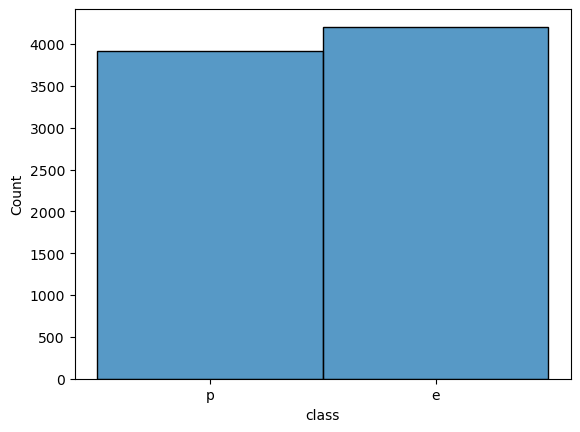

In [8]:
sns.histplot(data=df['class'])
plt.show()

Ustunlarimizda NaN qiymatlar bor yoki yo'qligini tekshiramiz

In [9]:
df.isna().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Bizning ustunlarimizda yashirin NaN qiymatlar bor yoki yo'qligini tekshiramiz

In [10]:
df.replace(r'[^a-zA-Z]', np.nan, regex=True).isna().sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [11]:
df = df.replace(r'[^a-zA-Z]', np.nan, regex=True)

Ko'rishimiz mumkunki `stalk-root` ustunida NaN qiymatlar mavjud

Ustunlarning taqsimotini ko'rib chiqamiz

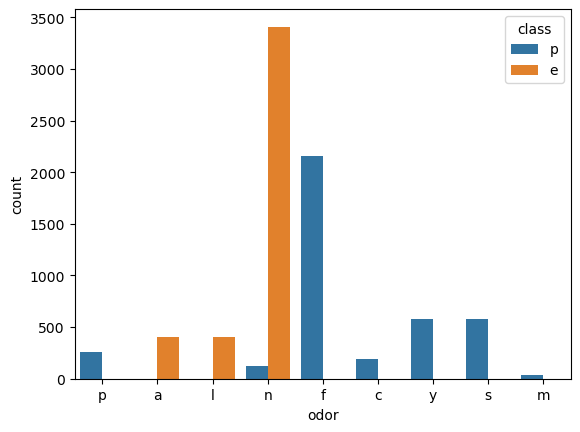

In [12]:
sns.countplot(x='odor', hue='class', data=df)
plt.show()

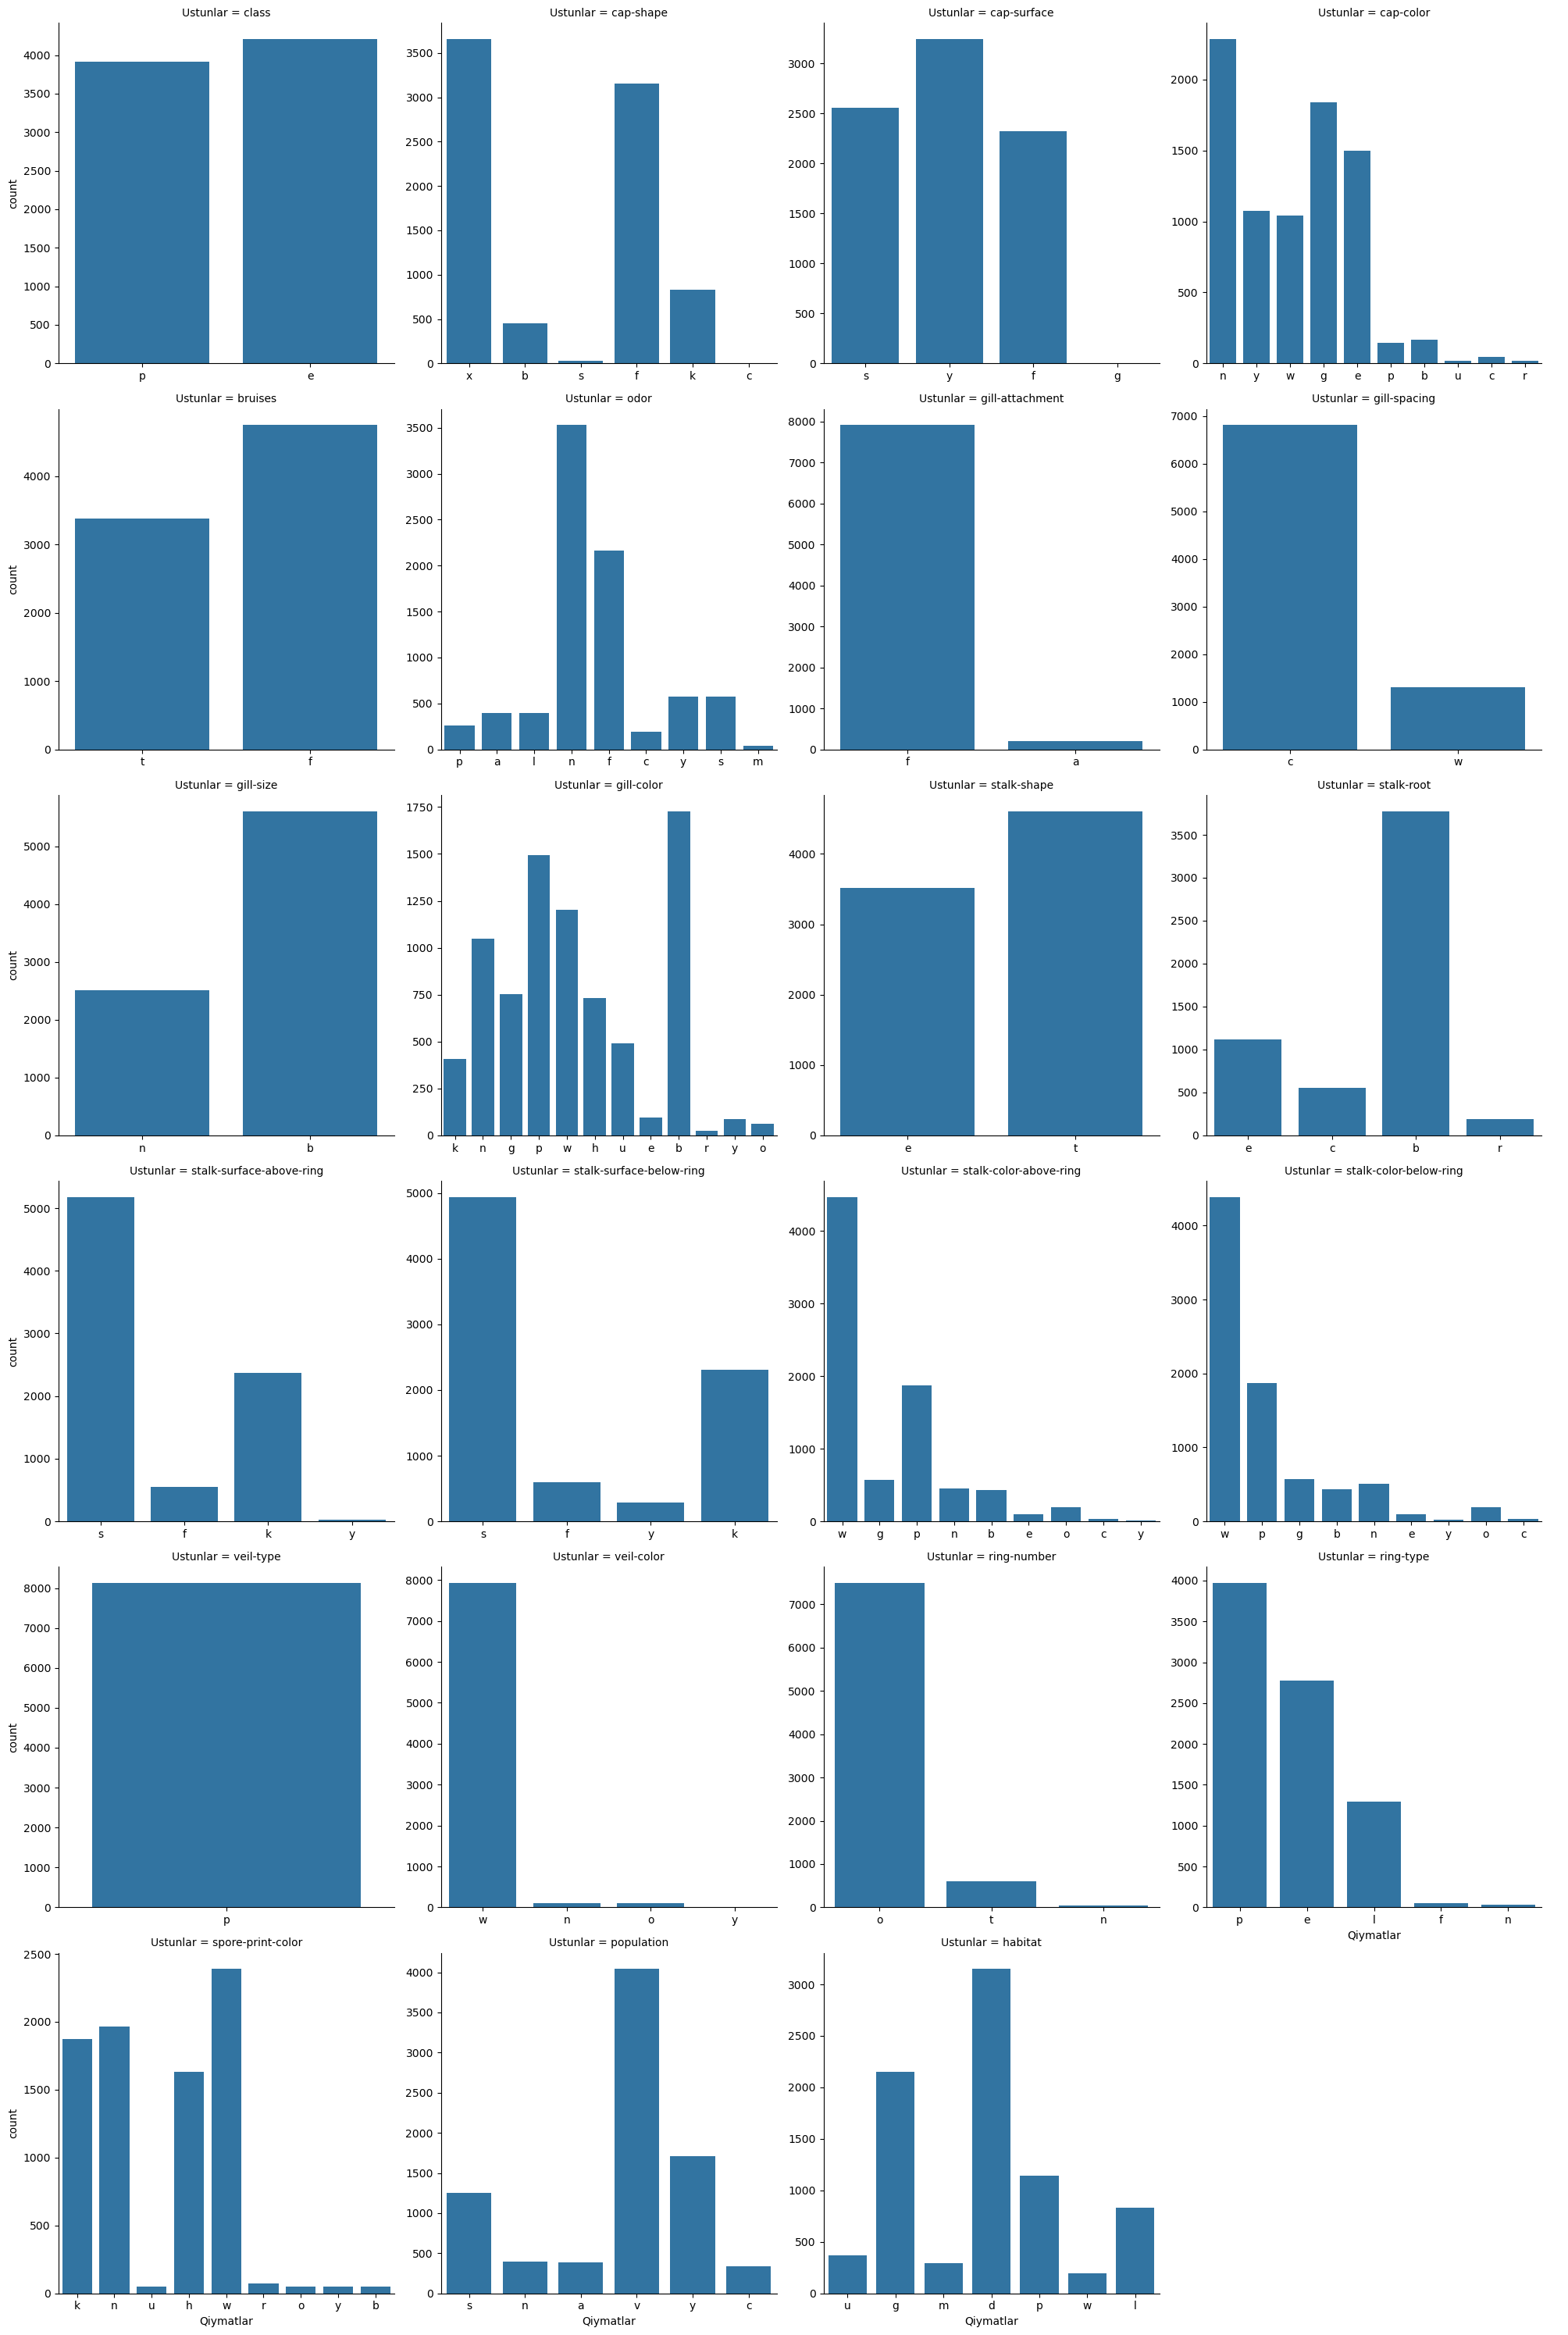

In [13]:
# 1. Datani "uzun" formatga o'tkazamiz
df_melted = df.melt(var_name='Ustunlar', value_name='Qiymatlar')

# 2. FacetGrid yordamida barcha ustunlar uchun countplot chizamiz
g = sns.catplot(
    data=df_melted, 
    x='Qiymatlar', 
    col='Ustunlar',
    kind='count', 
    col_wrap=4,  # Har qatorda 4 tadan grafik
    sharex=False, 
    sharey=False,
)
plt.show()

Yuqoridagi grafiklardan shunday xulosa qilishimiz mumkunki.  
- `veil-type`
- `gill-attachment`
- `veil-color`  
ustunlarining deyarli yaxlit qiymatdan iborat bo'lganligi uchun bizga foydasi kam bo'lishi mumkun.

Target ustun va qolgan ustunlar orasidagi bog'lanishni tahlil qilamiz

In [14]:
for col in df.columns:
    if col != 'class':
        print(f"\nColumn: {col}")
        print(pd.crosstab(df[col], df['class'], normalize='index'))


Column: cap-shape
class             e         p
cap-shape                    
b          0.893805  0.106195
c          0.000000  1.000000
f          0.506345  0.493655
k          0.275362  0.724638
s          1.000000  0.000000
x          0.532823  0.467177

Column: cap-surface
class               e         p
cap-surface                    
f            0.672414  0.327586
g            0.000000  1.000000
s            0.447574  0.552426
y            0.463625  0.536375

Column: cap-color
class             e         p
cap-color                    
b          0.285714  0.714286
c          0.727273  0.272727
e          0.416000  0.584000
g          0.560870  0.439130
n          0.553415  0.446585
p          0.388889  0.611111
r          1.000000  0.000000
u          1.000000  0.000000
w          0.692308  0.307692
y          0.373134  0.626866

Column: bruises
class           e         p
bruises                    
f        0.306655  0.693345
t        0.815166  0.184834

Column: odor
class 

Chi-Square (Xi-kvadrat) orqali qaysi ustunlar muhumekanligini aniqlaymiz

In [15]:
chi2_results = {}

for col in df.columns:
    if col != 'class': # Target ustundan tashqari hamma ustunni tekshiramiz
        con_table = pd.crosstab(df[col], df['class'])
        chi2, p, dof, expected = chi2_contingency(con_table)
        chi2_results[col] = p

# Natijalarni p-value bo'yicha tartiblaymiz (eng kichik p-value eng muhim ustun)
sorted_results = sorted(chi2_results.items(), key=lambda x: x[1])

for col, p_val in sorted_results:
    status = "Muhim ✅" if p_val < 0.05 else "Muhim emas ❌"
    print(f"{col}: p-value = {p_val:.10f} ({status})")

bruises: p-value = 0.0000000000 (Muhim ✅)
odor: p-value = 0.0000000000 (Muhim ✅)
gill-size: p-value = 0.0000000000 (Muhim ✅)
gill-color: p-value = 0.0000000000 (Muhim ✅)
stalk-surface-above-ring: p-value = 0.0000000000 (Muhim ✅)
stalk-surface-below-ring: p-value = 0.0000000000 (Muhim ✅)
stalk-color-above-ring: p-value = 0.0000000000 (Muhim ✅)
stalk-color-below-ring: p-value = 0.0000000000 (Muhim ✅)
ring-type: p-value = 0.0000000000 (Muhim ✅)
spore-print-color: p-value = 0.0000000000 (Muhim ✅)
population: p-value = 0.0000000000 (Muhim ✅)
habitat: p-value = 0.0000000000 (Muhim ✅)
gill-spacing: p-value = 0.0000000000 (Muhim ✅)
stalk-root: p-value = 0.0000000000 (Muhim ✅)
cap-shape: p-value = 0.0000000000 (Muhim ✅)
ring-number: p-value = 0.0000000000 (Muhim ✅)
cap-color: p-value = 0.0000000000 (Muhim ✅)
cap-surface: p-value = 0.0000000000 (Muhim ✅)
veil-color: p-value = 0.0000000000 (Muhim ✅)
gill-attachment: p-value = 0.0000000000 (Muhim ✅)
stalk-shape: p-value = 0.0000000000 (Muhim ✅)
ve

Test natijasidan ko'rishimiz mumkunki `veil-type` ustuning bizga foydasi yo'q

Endi ustunlarning foydalilik darajasini ham tekshirib olamiz  
Buning uchun zamonaviy `Mutual Information` usulini ishlatamiz

In [16]:
# 1. Ma'lumotlarni nusxalaymiz va Label Encoding qilamiz
df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# 2. X (belgilar) va y (target) ni ajratamiz
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

# 3. Mutual Information ni hisoblaymiz
# discrete_features=True - chunki bizda hamma ustunlar kategoriyali (diskret)
mi_scores = mutual_info_classif(X, y, discrete_features=True)

# 4. Natijani chiroyli ko'rinishga keltiramiz
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print(mi_results)

odor                        0.628043
spore-print-color           0.333199
gill-color                  0.289027
ring-type                   0.220436
stalk-surface-above-ring    0.197357
stalk-surface-below-ring    0.188463
stalk-color-above-ring      0.175952
stalk-color-below-ring      0.167337
gill-size                   0.159531
population                  0.139987
bruises                     0.133347
habitat                     0.108709
stalk-root                  0.093448
gill-spacing                0.069927
cap-shape                   0.033823
ring-number                 0.026653
cap-color                   0.024987
cap-surface                 0.019817
veil-color                  0.016509
gill-attachment             0.009818
stalk-shape                 0.005210
veil-type                   0.000000
dtype: float64


Yuqoridagi malumotlardan ham aniq bo'ldiki `veil-type` ustuni biz uchu keraksiz.  
Uni tashlab yuborishimiz mumkun. Bundan tashqari `stalk-root` ustunidagi NaN qiymatlar ko'p bo'lganligi  
va foydalilik darajasi past bo'lganligi uchun uni taxminiy qiymatlar bilan to'ldirishdan ko'ra tashlab yuborish  
masadga muvofiq bo'ladi. Chunki biz bu ustunni yoki `ffil yoki bfill` orqali to'ldirishimz kerak yoki qatorlarni tashhhlab  
yuborishimiz kerak. Qatorlarni tashlab yuborsak bizga kerakli juda ko'p malumotlardan ayrilamiz. 

In [17]:
df.to_csv("../data/processed/mushrooms_cleaned.csv")